# Lab 03 – Task 3: Edge Detection & Noise Reduction for Medical Imaging
**Application:** Medical image segmentation (X-ray / CT) – clean tissue borders before boundary extraction.

**Pipeline:** grayscale scan → add controlled noise → denoise (Gaussian vs Median, several kernel sizes) → Sobel (X, Y, magnitude) → Canny (tuned hysteresis) → **quantitative comparison of edge maps**.

> **Using your own scan:** set `IMAGE_PATH` in the first code cell (e.g. a chest X-ray `.png`). If left as `None`, a synthetic CT-like phantom is generated so the notebook runs anywhere.
> The clean scan is treated as ground truth; noise is added to it so every filter can be scored objectively.

In [1]:
import cv2, numpy as np, pandas as pd, matplotlib.pyplot as plt
try:
    from skimage.metrics import structural_similarity as ssim
except ImportError:
    ssim = None
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)

IMAGE_PATH = None        # e.g. "chest_xray.png"
RNG = np.random.default_rng(42)
TOL = 2                  # pixel tolerance when matching edges

## 1. Load the scan in grayscale

In [2]:
def make_phantom(n=512):
    """CT-like phantom (Shepp-Logan style): skull ring, brain, ventricles, lesions."""
    img = np.zeros((n, n), np.uint8)
    c = n // 2
    cv2.ellipse(img, (c, c), (int(n*.42), int(n*.48)), 0, 0, 360, 200, -1)   # skull
    cv2.ellipse(img, (c, c), (int(n*.38), int(n*.44)), 0, 0, 360, 110, -1)   # brain
    cv2.ellipse(img, (c-45, c-20), (45, 85), 15, 0, 360, 60, -1)             # ventricle L
    cv2.ellipse(img, (c+45, c-20), (45, 85), -15, 0, 360, 60, -1)            # ventricle R
    cv2.ellipse(img, (c, c+110), (28, 28), 0, 0, 360, 170, -1)               # lesion
    cv2.ellipse(img, (c+100, c+60), (18, 30), 30, 0, 360, 150, -1)           # lesion
    cv2.ellipse(img, (c-110, c+80), (22, 14), -20, 0, 360, 160, -1)          # lesion
    return cv2.GaussianBlur(img, (0, 0), 1.0)                                  # soft, realistic borders

if IMAGE_PATH:
    clean = cv2.imread(IMAGE_PATH, cv2.IMREAD_GRAYSCALE)
    assert clean is not None, "could not read image"
    clean = cv2.resize(clean, (512, 512), interpolation=cv2.INTER_AREA)
else:
    clean = make_phantom()
print("clean image:", clean.shape, clean.dtype, "range", clean.min(), "-", clean.max())

clean image: (512, 512) uint8 range 0 - 200


## 2. Simulate scan noise
Two realistic noise types, because they behave very differently under linear vs non-linear filters:
* **Gaussian noise** (σ = 20) – electronic/quantum noise in X-ray detectors.
* **Salt-and-pepper noise** (4 % of pixels) – dead pixels / transmission errors.

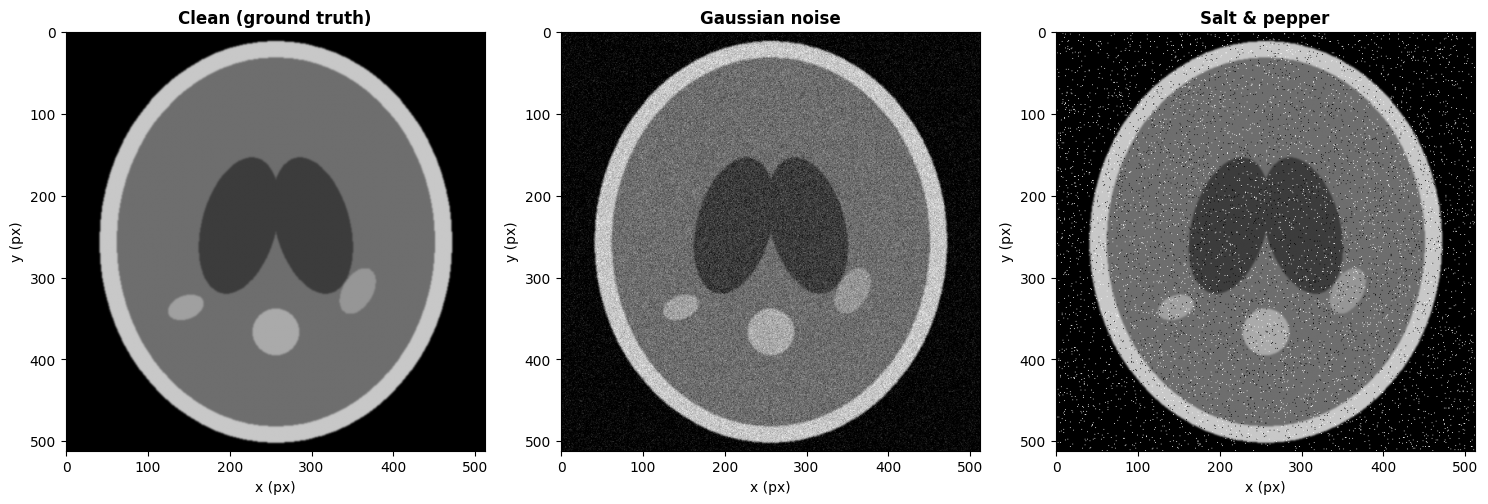

In [3]:
def add_gaussian(img, sigma=20):
    return np.clip(img.astype(np.float32) + RNG.normal(0, sigma, img.shape), 0, 255).astype(np.uint8)

def add_salt_pepper(img, amount=0.04):
    out = img.copy()
    r = RNG.random(img.shape)
    out[r < amount/2] = 0
    out[r > 1 - amount/2] = 255
    return out

noisy = {"Gaussian noise": add_gaussian(clean), "Salt & pepper": add_salt_pepper(clean)}

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
for a, (t, im) in zip(ax, [("Clean (ground truth)", clean), *noisy.items()]):
    a.imshow(im, cmap="gray", vmin=0, vmax=255); a.set_title(t, fontweight="bold")
    a.set_xlabel("x (px)"); a.set_ylabel("y (px)")
plt.tight_layout(); plt.show()

## 3. Noise suppression: Gaussian blur vs Median filter
Kernel sizes 3, 5 and 9 are compared. Quality is measured against the clean image with **PSNR** (dB, higher = better) and **SSIM** (0–1, higher = better).

In [4]:
def psnr(a, b):
    mse = np.mean((a.astype(np.float64) - b.astype(np.float64))**2)
    return float("inf") if mse == 0 else 10*np.log10(255**2 / mse)

KS = [3, 5, 9]
def build_filters(img):
    f = {"No filter": img}
    for k in KS: f[f"Gaussian k={k}"] = cv2.GaussianBlur(img, (k, k), 0)
    for k in KS: f[f"Median k={k}"]   = cv2.medianBlur(img, k)
    return f

filtered = {n: build_filters(im) for n, im in noisy.items()}

rows = []
for nname, fd in filtered.items():
    for fname, im in fd.items():
        rows.append({"Noise": nname, "Filter": fname, "PSNR (dB)": round(psnr(clean, im), 2),
                     "SSIM": round(ssim(clean, im, data_range=255), 4) if ssim else np.nan})
df_denoise = pd.DataFrame(rows)
df_denoise

,Noise,Filter,PSNR (dB),SSIM
0,Gaussian noise,No filter,23.00,0.1790
1,Gaussian noise,Gaussian k=3,29.86,0.4491
2,Gaussian noise,Gaussian k=5,31.00,0.5427
3,Gaussian noise,Gaussian k=9,30.56,0.6311
4,Gaussian noise,Median k=3,30.55,0.5288
5,Gaussian noise,Median k=5,34.00,0.7562
6,Gaussian noise,Median k=9,35.17,0.8938
7,Salt & pepper,No filter,18.44,0.3312
8,Salt & pepper,Gaussian k=3,26.55,0.4784
9,Salt & pepper,Gaussian k=5,28.67,0.5613


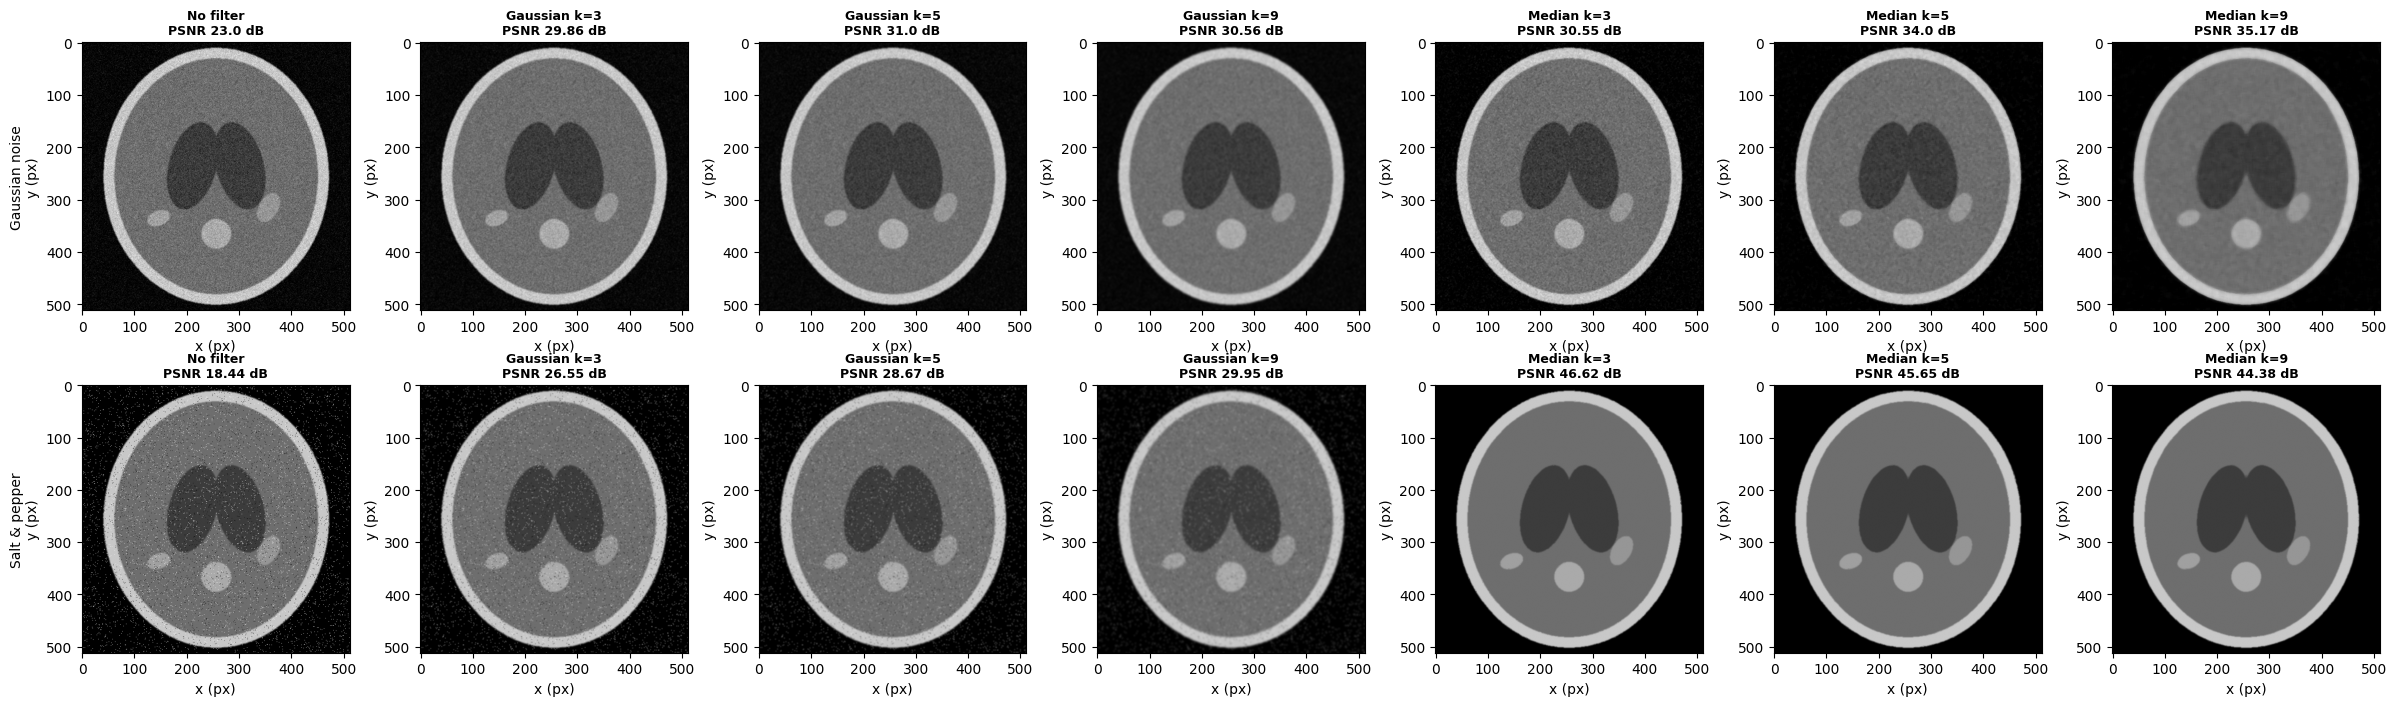

In [5]:
fig, ax = plt.subplots(2, 7, figsize=(24, 7))
for r, (nname, fd) in enumerate(filtered.items()):
    for c, (fname, im) in enumerate(fd.items()):
        ax[r, c].imshow(im, cmap="gray", vmin=0, vmax=255)
        p = df_denoise[(df_denoise.Noise == nname) & (df_denoise.Filter == fname)]["PSNR (dB)"].item()
        ax[r, c].set_title(f"{fname}\nPSNR {p} dB", fontsize=9, fontweight="bold")
        ax[r, c].set_xlabel("x (px)"); ax[r, c].set_ylabel("y (px)")
    ax[r, 0].set_ylabel(f"{nname}\ny (px)")
plt.tight_layout(); plt.show()

## 4. Sobel gradients (X, Y, magnitude)
`cv2.Sobel` is computed in 64-bit float (so negative gradients aren't clipped), then
$|G| = \sqrt{G_x^2 + G_y^2}$.

Quantitative metric – **Edge-to-Background Ratio (EBR)**: mean gradient magnitude on true tissue borders ÷ mean magnitude in flat regions. Higher = borders stand out more clearly against noise.

In [6]:
def sobel_all(img, ksize=3):
    gx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=ksize)
    gy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=ksize)
    return gx, gy, np.hypot(gx, gy)

# ground-truth edge map from the clean image
gt_edges = cv2.Canny(clean, 30, 90)
near_edge = cv2.dilate(gt_edges, np.ones((15, 15), np.uint8)) > 0
edge_mask, flat_mask = gt_edges > 0, ~near_edge

def ebr(mag):
    # capped at 999: a perfectly denoised flat region has ~0 gradient, which would give an infinite ratio
    return min(mag[edge_mask].mean() / max(mag[flat_mask].mean(), 1e-6), 999.0)

sobel_rows, sobel_store = [], {}
for nname, fd in filtered.items():
    for fname, im in fd.items():
        gx, gy, mag = sobel_all(im)
        sobel_store[(nname, fname)] = (gx, gy, mag)
        sobel_rows.append({"Noise": nname, "Filter": fname,
                           "Mean |G| on edges": round(mag[edge_mask].mean(), 1),
                           "Mean |G| flat": round(mag[flat_mask].mean(), 1),
                           "EBR": round(ebr(mag), 2)})
df_sobel = pd.DataFrame(sobel_rows)
df_sobel

,Noise,Filter,Mean |G| on edges,Mean |G| flat,EBR
0,Gaussian noise,No filter,319.2,69.9,4.56
1,Gaussian noise,Gaussian k=3,267.5,33.6,7.96
2,Gaussian noise,Gaussian k=5,237.3,22.2,10.68
3,Gaussian noise,Gaussian k=9,180.2,10.2,17.72
4,Gaussian noise,Median k=3,285.9,30.9,9.25
5,Gaussian noise,Median k=5,265.2,15.7,16.93
6,Gaussian noise,Median k=9,241.4,6.8,35.67
7,Salt & pepper,No filter,323.3,64.7,5.00
8,Salt & pepper,Gaussian k=3,263.0,42.4,6.20
9,Salt & pepper,Gaussian k=5,232.2,31.8,7.30


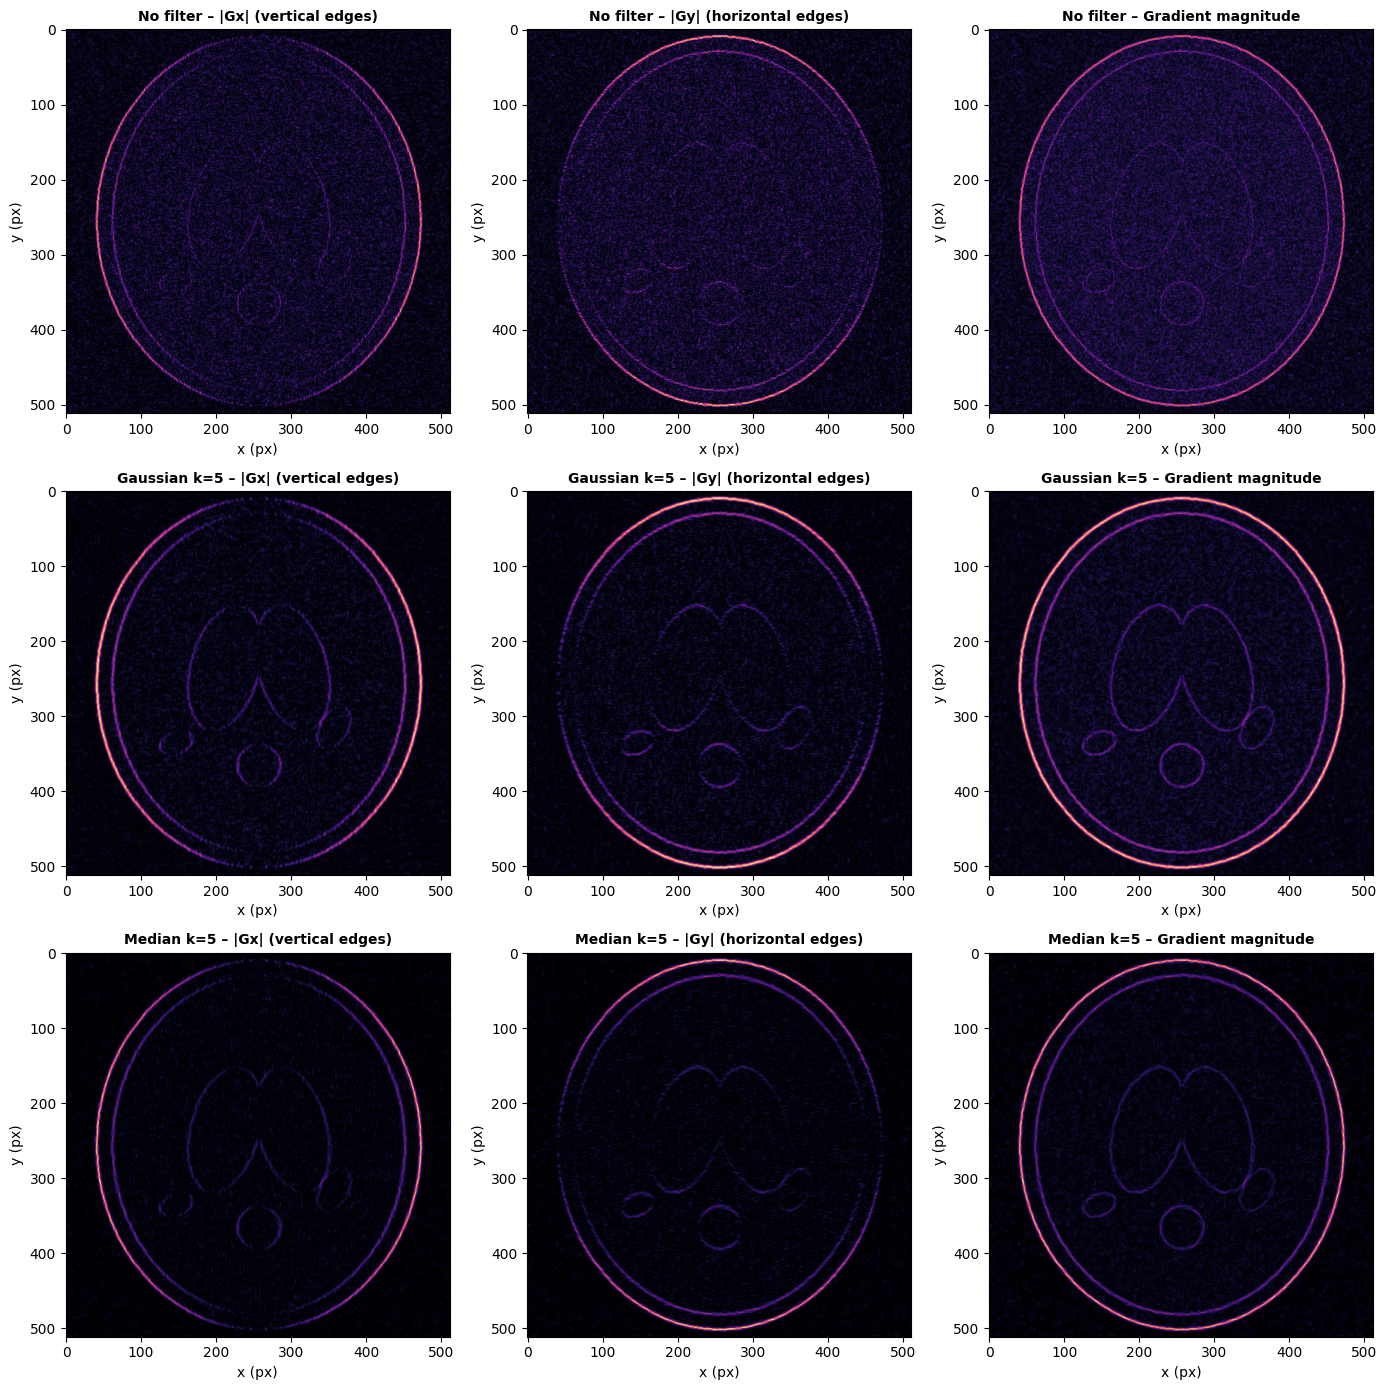

In [7]:
# visual: Sobel X / Y / magnitude for the Gaussian-noise case, best vs worst filter
show = [("Gaussian noise", "No filter"), ("Gaussian noise", "Gaussian k=5"), ("Gaussian noise", "Median k=5")]
fig, ax = plt.subplots(3, 3, figsize=(14, 14))
for r, key in enumerate(show):
    gx, gy, mag = sobel_store[key]
    for c, (im, t) in enumerate([(np.abs(gx), "|Gx| (vertical edges)"), (np.abs(gy), "|Gy| (horizontal edges)"), (mag, "Gradient magnitude")]):
        ax[r, c].imshow(im, cmap="magma"); ax[r, c].set_title(f"{key[1]} – {t}", fontsize=10, fontweight="bold")
        ax[r, c].set_xlabel("x (px)"); ax[r, c].set_ylabel("y (px)")
plt.tight_layout(); plt.show()

## 5. Canny edge detection with tuned hysteresis thresholds
Canny keeps a pixel if its gradient is above **T_upper**, or above **T_lower** *and* connected to a strong edge.
Thresholds are **tuned per filter** by grid search (T_lower ∈ 10…100, T_upper = 2× or 3× T_lower) maximising the edge **F1-score** against the ground-truth edge map (matched within ±2 px). A fixed default (50, 150) is also reported to show why tuning matters.

In [8]:
def edge_scores(pred, gt, tol=TOL):
    pred_b, gt_b = pred > 0, gt > 0
    if pred_b.sum() == 0: return 0.0, 0.0, 0.0
    d_gt   = cv2.distanceTransform((~gt_b).astype(np.uint8), cv2.DIST_L2, 3)    # distance to nearest GT edge
    d_pred = cv2.distanceTransform((~pred_b).astype(np.uint8), cv2.DIST_L2, 3)  # distance to nearest predicted edge
    precision = (d_gt[pred_b] <= tol).mean()
    recall    = (d_pred[gt_b] <= tol).mean()
    f1 = 0.0 if precision + recall == 0 else 2*precision*recall/(precision+recall)
    return precision, recall, f1

def tune_canny(img):
    best = (-1, None)
    for lo in range(10, 101, 10):
        for ratio in (2, 3):
            hi = lo * ratio
            f1 = edge_scores(cv2.Canny(img, lo, hi), gt_edges)[2]
            if f1 > best[0]: best = (f1, (lo, hi))
    return best[1]

canny_rows, canny_maps = [], {}
for nname, fd in filtered.items():
    for fname, im in fd.items():
        lo, hi = tune_canny(im)
        e_tuned, e_def = cv2.Canny(im, lo, hi), cv2.Canny(im, 50, 150)
        p, r, f1 = edge_scores(e_tuned, gt_edges)
        _, _, f1_def = edge_scores(e_def, gt_edges)
        canny_maps[(nname, fname)] = (e_tuned, (lo, hi))
        canny_rows.append({"Noise": nname, "Filter": fname, "T_lower": lo, "T_upper": hi,
                           "Precision": round(p, 3), "Recall": round(r, 3), "F1 (tuned)": round(f1, 3),
                           "F1 (50,150)": round(f1_def, 3),
                           "Edge density %": round(100*(e_tuned > 0).mean(), 2),
                           "Spurious px": int(((e_tuned > 0) & ~(cv2.dilate(gt_edges, np.ones((2*TOL+1,)*2, np.uint8)) > 0)).sum())})
df_canny = pd.DataFrame(canny_rows)
df_canny

,Noise,Filter,T_lower,T_upper,Precision,Recall,F1 (tuned),"F1 (50,150)",Edge density %,Spurious px
0,Gaussian noise,No filter,100,300,0.284,0.989,0.441,0.149,7.64,13665
1,Gaussian noise,Gaussian k=3,100,200,0.968,0.972,0.970,0.471,1.85,100
2,Gaussian noise,Gaussian k=5,70,140,0.990,0.992,0.991,0.980,1.79,28
3,Gaussian noise,Gaussian k=9,30,90,0.999,0.999,0.999,0.887,1.74,3
4,Gaussian noise,Median k=3,100,200,0.912,0.971,0.940,0.441,1.99,355
5,Gaussian noise,Median k=5,60,120,0.958,0.997,0.977,0.967,1.93,121
6,Gaussian noise,Median k=9,30,90,0.969,0.983,0.976,0.880,1.85,87
7,Salt & pepper,No filter,100,300,0.160,0.978,0.276,0.213,12.88,27414
8,Salt & pepper,Gaussian k=3,100,300,0.548,0.900,0.682,0.241,3.17,3463
9,Salt & pepper,Gaussian k=5,90,270,0.867,0.729,0.792,0.436,1.53,471


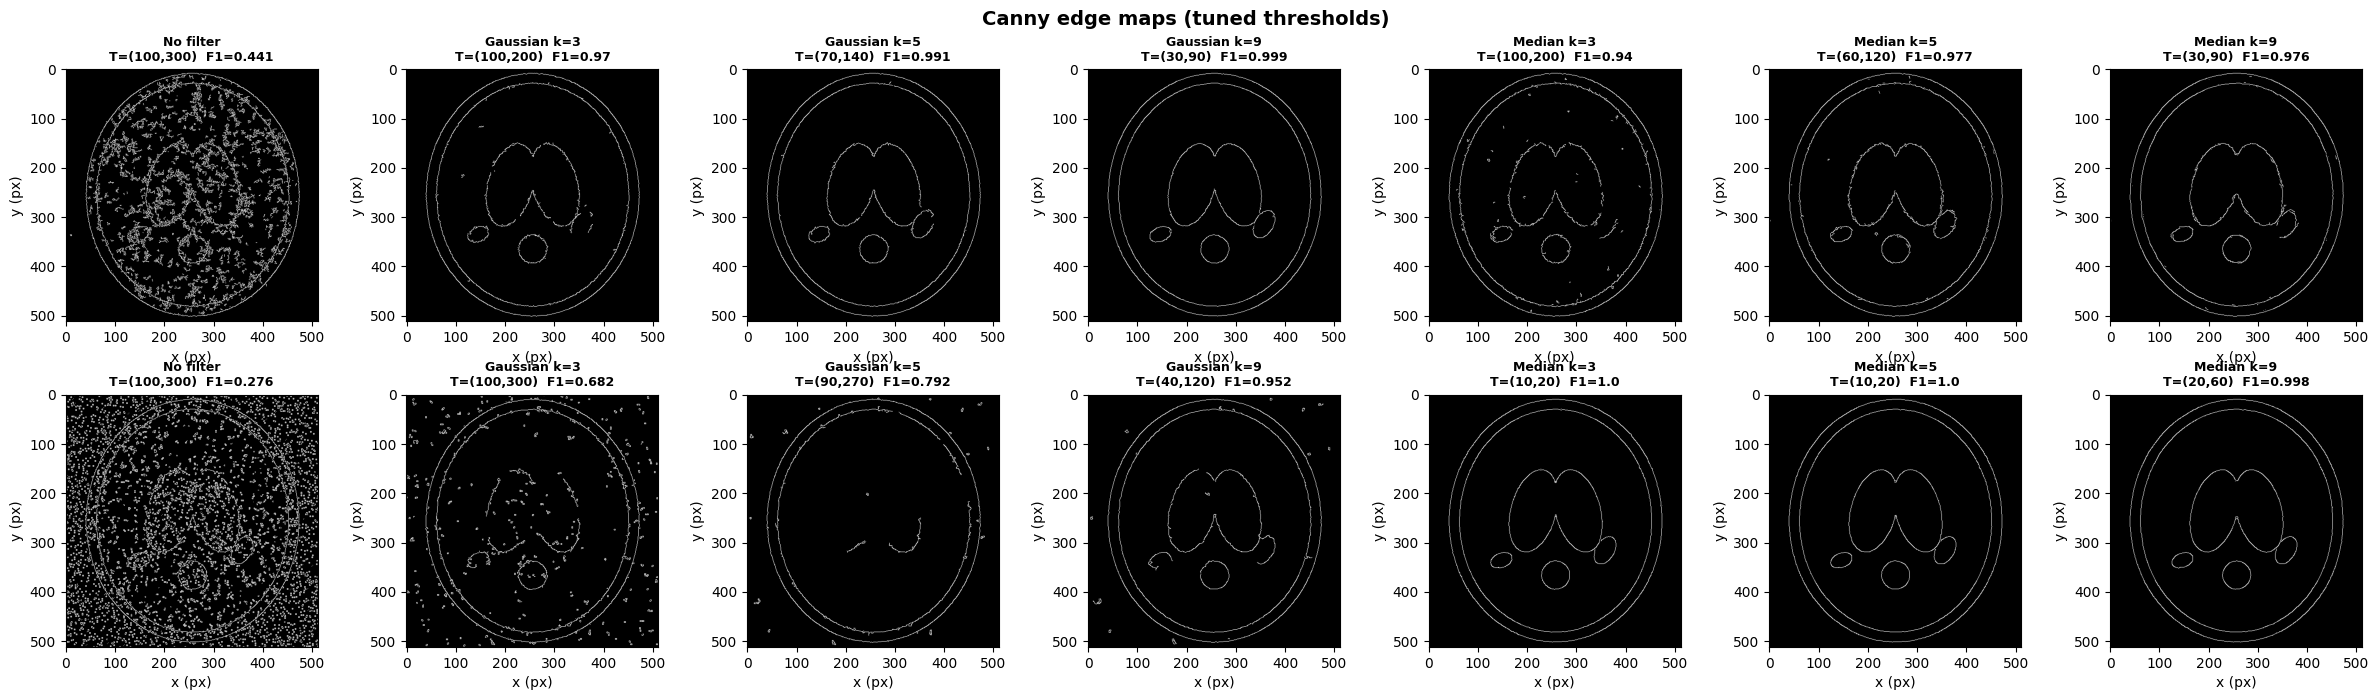

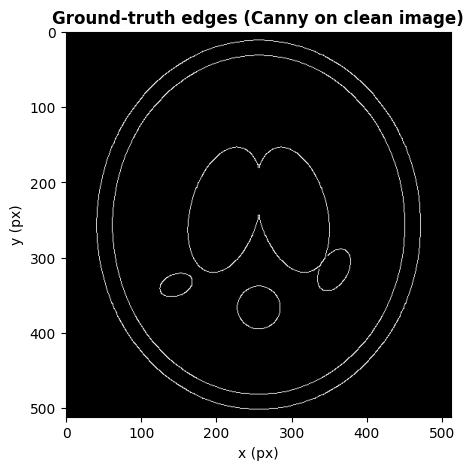

In [9]:
fig, ax = plt.subplots(2, 7, figsize=(24, 7))
for r, nname in enumerate(filtered):
    for c, fname in enumerate(filtered[nname]):
        e, (lo, hi) = canny_maps[(nname, fname)]
        f1 = df_canny[(df_canny.Noise == nname) & (df_canny.Filter == fname)]["F1 (tuned)"].item()
        ax[r, c].imshow(e, cmap="gray"); ax[r, c].set_title(f"{fname}\nT=({lo},{hi})  F1={f1}", fontsize=9, fontweight="bold")
        ax[r, c].set_xlabel("x (px)"); ax[r, c].set_ylabel("y (px)")
plt.suptitle("Canny edge maps (tuned thresholds)", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 1, figsize=(5, 5)); ax.imshow(gt_edges, cmap="gray")
ax.set_title("Ground-truth edges (Canny on clean image)", fontweight="bold"); ax.set_xlabel("x (px)"); ax.set_ylabel("y (px)"); plt.show()

## 6. Combined quantitative comparison

In [10]:
summary = (df_denoise.merge(df_sobel[["Noise", "Filter", "EBR"]], on=["Noise", "Filter"])
                     .merge(df_canny[["Noise", "Filter", "T_lower", "T_upper", "Precision", "Recall", "F1 (tuned)", "F1 (50,150)", "Spurious px"]], on=["Noise", "Filter"]))
summary.to_csv("task3_results.csv", index=False)
summary

,Noise,Filter,PSNR (dB),SSIM,EBR,T_lower,T_upper,Precision,Recall,F1 (tuned),"F1 (50,150)",Spurious px
0,Gaussian noise,No filter,23.00,0.1790,4.56,100,300,0.284,0.989,0.441,0.149,13665
1,Gaussian noise,Gaussian k=3,29.86,0.4491,7.96,100,200,0.968,0.972,0.970,0.471,100
2,Gaussian noise,Gaussian k=5,31.00,0.5427,10.68,70,140,0.990,0.992,0.991,0.980,28
3,Gaussian noise,Gaussian k=9,30.56,0.6311,17.72,30,90,0.999,0.999,0.999,0.887,3
4,Gaussian noise,Median k=3,30.55,0.5288,9.25,100,200,0.912,0.971,0.940,0.441,355
5,Gaussian noise,Median k=5,34.00,0.7562,16.93,60,120,0.958,0.997,0.977,0.967,121
6,Gaussian noise,Median k=9,35.17,0.8938,35.67,30,90,0.969,0.983,0.976,0.880,87
7,Salt & pepper,No filter,18.44,0.3312,5.00,100,300,0.160,0.978,0.276,0.213,27414
8,Salt & pepper,Gaussian k=3,26.55,0.4784,6.20,100,300,0.548,0.900,0.682,0.241,3463
9,Salt & pepper,Gaussian k=5,28.67,0.5613,7.30,90,270,0.867,0.729,0.792,0.436,471


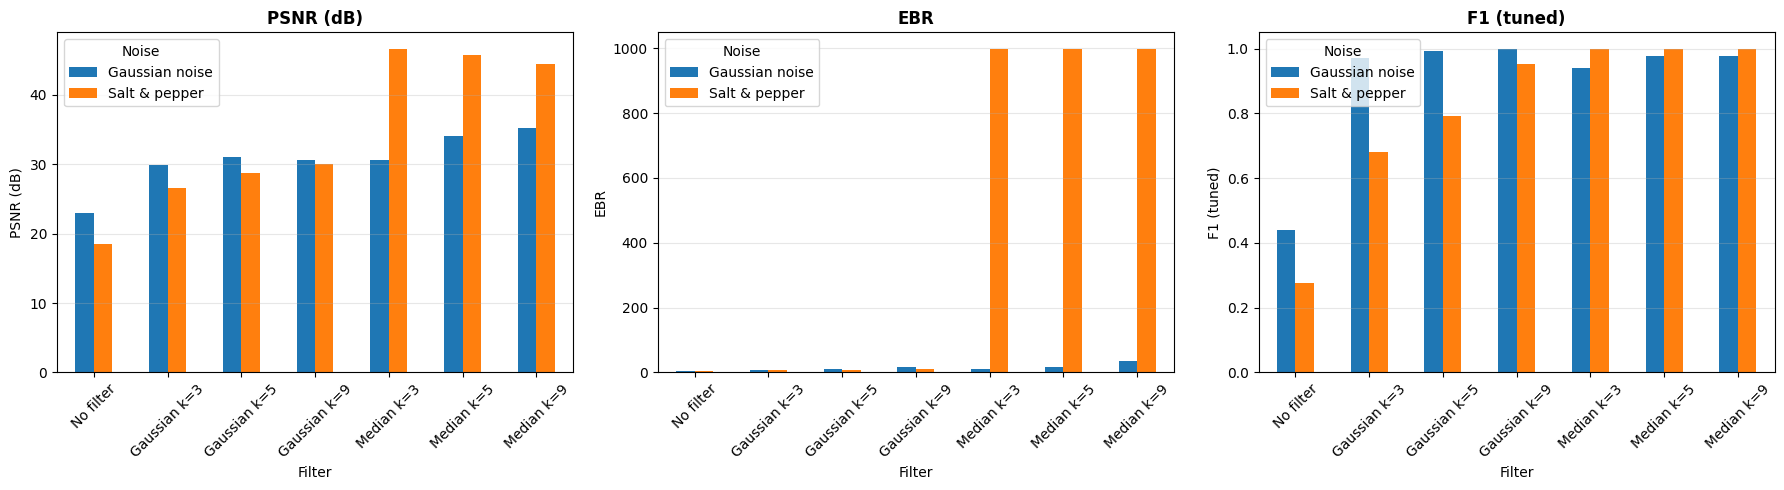

Best filter per noise type (by tuned edge F1):
  Gaussian noise : Gaussian k=9   F1=0.999  PSNR=30.56 dB  T=(30,90)
  Salt & pepper  : Median k=3     F1=1.0  PSNR=46.62 dB  T=(10,20)


In [11]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
for a, metric in zip(ax, ["PSNR (dB)", "EBR", "F1 (tuned)"]):
    piv = summary.pivot(index="Filter", columns="Noise", values=metric).loc[list(filtered["Gaussian noise"].keys())]
    piv.plot.bar(ax=a, rot=45); a.set_title(metric, fontweight="bold"); a.set_xlabel("Filter"); a.set_ylabel(metric); a.grid(axis="y", alpha=.3)
plt.tight_layout(); plt.show()

print("Best filter per noise type (by tuned edge F1):")
for nname, g in summary.groupby("Noise"):
    b = g.loc[g["F1 (tuned)"].idxmax()]
    print(f"  {nname:<15}: {b['Filter']:<14} F1={b['F1 (tuned)']}  PSNR={b['PSNR (dB)']} dB  T=({b['T_lower']},{b['T_upper']})")

## 7. Conclusions (from the run on the synthetic CT phantom)

| Observation | Evidence |
|---|---|
| **Filtering is essential.** Canny on the raw noisy image produces thousands of false edge pixels. | No filter: tuned F1 = 0.44 (Gaussian noise) and 0.28 (salt & pepper), with 13 665 and 27 414 spurious pixels. |
| **Match the filter to the noise type.** Median wins on impulse noise; Gaussian blur is adequate for Gaussian noise. | Salt & pepper: Median k=3 gives PSNR 46.6 dB and F1 = 1.00, while Gaussian k=5 only reaches F1 = 0.79 because it smears each impulse into its neighbours. |
| **Median preserves borders better at equal strength.** | Gaussian noise, k=9: Median SSIM 0.894 vs Gaussian 0.631; PSNR 35.2 dB vs 30.6 dB. |
| **Bigger kernels trade detail for smoothness.** Gaussian k=9 gave the best edge F1 here (0.999), but only because the phantom has large smooth regions; it would blur thin structures in a real scan. | Edge F1 rises with Gaussian kernel size while EBR climbs from 7.96 (k=3) to 17.72 (k=9). |
| **Hysteresis thresholds must be re-tuned for every filter.** Stronger smoothing lowers gradient magnitudes, so the optimal thresholds drop. | Tuned T_lower: 100 (k=3) to 30 (k=9) for Gaussian; fixed (50,150) scores F1 = 0.47 on Gaussian k=3 versus 0.97 when tuned. |

**Caveat:** the phantom is piecewise-constant, which flatters the median filter (perfect scores, infinite-ratio EBR capped at 999). Real X-ray/CT scans contain texture and fine structures, so expect lower absolute scores and a smaller median kernel (3–5) as the safe choice. Run the notebook with `IMAGE_PATH` set to a real scan to reproduce the comparison on it.